In [10]:
import sys
import pandas as pd

from src.data import load_data
from src.missingness import introduce_missingness
from src.evaluation import evaluate_model

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = load_data()

In [11]:
# Complete-data baseline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

results = []

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42)
}

for model_name, model in models.items():

    if model_name == "Logistic Regression":

        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("model", model)
        ])

    else:

        pipeline = Pipeline([
            ("model", model)
        ])

    pipeline.fit(X_train, y_train)

    metrics = evaluate_model(
        pipeline,
        X_test,
        y_test
    )

    results.append({
        "missingness": 0,
        "seed": 0,
        "imputer": "None",
        "model": model_name,
        "accuracy": metrics["accuracy"],
        "f1": metrics["f1"],
        "auc": metrics["auc"],
        "rows_remaining": len(X_train)
    })

In [12]:
missing_rates = [0.10, 0.20, 0.30, 0.50]
seeds = [1, 2, 3, 4, 5]

imputers = {
    "Mean": SimpleImputer(strategy="mean"),
    "Median": SimpleImputer(strategy="median")
}

for missing_rate in missing_rates:
    for seed in seeds:

        # Introduce the same MCAR missingness
        X_train_missing = introduce_missingness(
            X_train,
            missing_rate,
            random_state=seed
        )

        X_test_missing = introduce_missingness(
            X_test,
            missing_rate,
            random_state=seed
        )
        
        # Complete-case analysis
        X_train_complete = X_train_missing.dropna()
        y_train_complete = y_train.loc[X_train_complete.index]

        X_test_complete = X_test_missing.dropna()
        y_test_complete = y_test.loc[X_test_complete.index]

        # Count remaining rows
        train_rows_remaining = len(X_train_complete)
        test_rows_remaining = len(X_test_complete)

        if (
            train_rows_remaining >= 10
            and y_train_complete.nunique() >= 2
            and test_rows_remaining >= 1
            and y_test_complete.nunique() >= 2
        ):
            for model_name, model in models.items():

                if model_name == "Logistic Regression":

                    pipeline = Pipeline([
                        ("scaler", StandardScaler()),
                        ("model", model)
                    ])

                else:

                    pipeline = Pipeline([
                        ("model", model)
                    ])

                pipeline.fit(
                    X_train_complete,
                    y_train_complete
                )

                metrics = evaluate_model(
                    pipeline,
                    X_test_complete,
                    y_test_complete
                )

                results.append({
                    "missingness": missing_rate,
                    "seed": seed,
                    "imputer": "Complete-case",
                    "model": model_name,
                    "accuracy": metrics["accuracy"],
                    "f1": metrics["f1"],
                    "auc": metrics["auc"],
                    "rows_remaining": train_rows_remaining
                })

        # Imputation methods (Mean/Median)
        for imputer_name, imputer in imputers.items():
            for model_name, model in models.items():
                if model_name == "Logistic Regression":

                    pipeline = Pipeline([
                        ("imputer", imputer),
                        ("scaler", StandardScaler()),
                        ("model", model)
                    ])

                else:

                    pipeline = Pipeline([
                        ("imputer", imputer),
                        ("model", model)
                    ])

                pipeline.fit(
                    X_train_missing,
                    y_train
                )

                metrics = evaluate_model(
                    pipeline,
                    X_test_missing,
                    y_test
                )

                results.append({
                    "missingness": missing_rate,
                    "seed": seed,
                    "imputer": imputer_name,
                    "model": model_name,
                    "accuracy": metrics["accuracy"],
                    "f1": metrics["f1"],
                    "auc": metrics["auc"],
                    "rows_remaining": len(X_train_missing)
                })

        # KNN - scale before imputation
        for model_name, model in models.items():

            pipeline = Pipeline([
                ("scaler", StandardScaler()),
                ("imputer", KNNImputer(n_neighbors=5)),
                ("model", model)
            ])

            pipeline.fit(
                X_train_missing,
                y_train
            )

            metrics = evaluate_model(
                pipeline,
                X_test_missing,
                y_test
            )

            results.append({
                "missingness": missing_rate,
                "seed": seed,
                "imputer": "KNN",
                "model": model_name,
                "accuracy": metrics["accuracy"],
                "f1": metrics["f1"],
                "auc": metrics["auc"],
                "rows_remaining": len(X_train_missing)
            })

results_df = pd.DataFrame(results)

results_df

,missingness,seed,imputer,model,accuracy,f1,auc,rows_remaining
0,0.0,0,None,Logistic Regression,0.982456,0.986111,0.995370,455
1,0.0,0,None,Random Forest,0.956140,0.965517,0.993717,455
2,0.1,1,Mean,Logistic Regression,0.956140,0.965035,0.993056,455
3,0.1,1,Mean,Random Forest,0.947368,0.958333,0.990079,455
4,0.1,1,Median,Logistic Regression,0.947368,0.957746,0.993056,455
...,...,...,...,...,...,...,...,...
123,0.5,5,Mean,Random Forest,0.929825,0.944444,0.985119,455
124,0.5,5,Median,Logistic Regression,0.929825,0.944444,0.987765,455
125,0.5,5,Median,Random Forest,0.929825,0.944444,0.982474,455
126,0.5,5,KNN,Logistic Regression,0.938596,0.951049,0.993717,455


In [13]:
results_df.groupby(
    ["missingness", "imputer", "model"]
).size()

missingness  imputer        model              
0.0          None           Logistic Regression    1
                            Random Forest          1
0.1          Complete-case  Logistic Regression    3
                            Random Forest          3
             KNN            Logistic Regression    5
                            Random Forest          5
             Mean           Logistic Regression    5
                            Random Forest          5
             Median         Logistic Regression    5
                            Random Forest          5
0.2          KNN            Logistic Regression    5
                            Random Forest          5
             Mean           Logistic Regression    5
                            Random Forest          5
             Median         Logistic Regression    5
                            Random Forest          5
0.3          KNN            Logistic Regression    5
                            Random Forest          

In [14]:
results_df.to_csv(
    "results/imputation_results.csv",
    index=False
)

In [15]:
summary = (
    results_df
    .groupby(["missingness", "imputer", "model"])
    .agg(
        n_runs=("accuracy", "count"),
        mean_accuracy=("accuracy", "mean"),
        std_accuracy=("accuracy", "std"),
        mean_f1=("f1", "mean"),
        std_f1=("f1", "std"),
        mean_auc=("auc", "mean"),
        std_auc=("auc", "std"),
        mean_rows_remaining=("rows_remaining", "mean")
    )
    .reset_index()
)

summary

,missingness,imputer,model,n_runs,mean_accuracy,std_accuracy,mean_f1,std_f1,mean_auc,std_auc,mean_rows_remaining
0,0.0,None,Logistic Regression,1,0.982456,NaN,0.986111,NaN,0.995370,NaN,455.000000
1,0.0,None,Random Forest,1,0.956140,NaN,0.965517,NaN,0.993717,NaN,455.000000
2,0.1,Complete-case,Logistic Regression,3,0.952381,0.082479,0.969697,0.052486,1.000000,0.000000,19.666667
3,0.1,Complete-case,Random Forest,3,0.952381,0.082479,0.962963,0.064150,0.966667,0.057735,19.666667
4,0.1,KNN,Logistic Regression,5,0.971930,0.011437,0.977758,0.009144,0.994312,0.001468,455.000000
5,0.1,KNN,Random Forest,5,0.942105,0.010002,0.953922,0.008302,0.992526,0.001055,455.000000
6,0.1,Mean,Logistic Regression,5,0.961404,0.013303,0.969131,0.010786,0.993915,0.001008,455.000000
7,0.1,Mean,Random Forest,5,0.938596,0.012405,0.950966,0.010429,0.991501,0.000910,455.000000
8,0.1,Median,Logistic Regression,5,0.956140,0.006203,0.964837,0.004984,0.993452,0.001082,455.000000
9,0.1,Median,Random Forest,5,0.935088,0.014678,0.947990,0.012441,0.991270,0.001854,455.000000


In [16]:
summary.to_csv(
    "results/imputation_summary.csv",
    index=False
)

In [17]:
# Calculate AUC loss
baseline = (
    summary[summary["missingness"] == 0]
    .set_index("model")["mean_auc"]
)

summary["auc_loss"] = summary.apply(
    lambda row: baseline[row["model"]] - row["mean_auc"],
    axis=1
)

In [18]:
# Summary table focusing on AUC
summary[
    [
        "missingness",
        "imputer",
        "model",
        "mean_auc",
        "std_auc",
        "auc_loss"
    ]
]

,missingness,imputer,model,mean_auc,std_auc,auc_loss
0,0.0,None,Logistic Regression,0.995370,NaN,0.000000
1,0.0,None,Random Forest,0.993717,NaN,0.000000
2,0.1,Complete-case,Logistic Regression,1.000000,0.000000,-0.004630
3,0.1,Complete-case,Random Forest,0.966667,0.057735,0.027050
4,0.1,KNN,Logistic Regression,0.994312,0.001468,0.001058
5,0.1,KNN,Random Forest,0.992526,0.001055,0.001190
6,0.1,Mean,Logistic Regression,0.993915,0.001008,0.001455
7,0.1,Mean,Random Forest,0.991501,0.000910,0.002216
8,0.1,Median,Logistic Regression,0.993452,0.001082,0.001918
9,0.1,Median,Random Forest,0.991270,0.001854,0.002447


## Visualisations


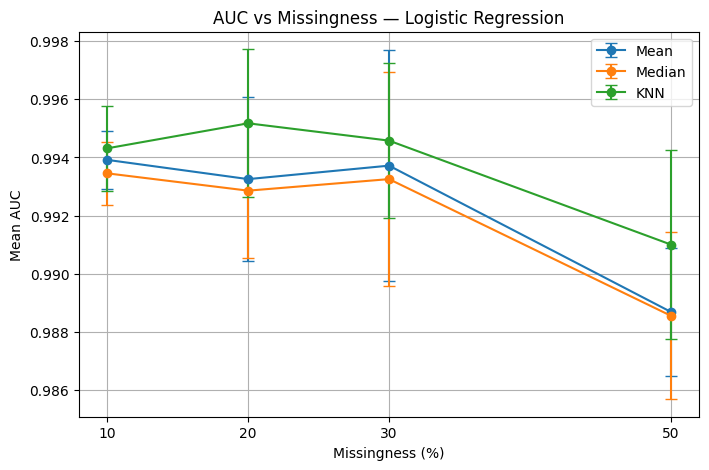

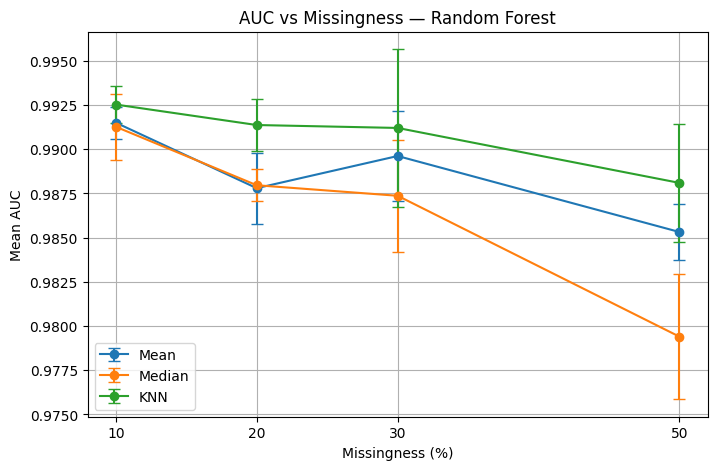

In [19]:
import matplotlib.pyplot as plt

imputation_summary = summary[
    summary["imputer"].isin(["Mean", "Median", "KNN"])
]

for model in ["Logistic Regression", "Random Forest"]:
    
    model_data = imputation_summary[
        imputation_summary["model"] == model
    ]

    plt.figure(figsize=(8, 5))

    for imputer in ["Mean", "Median", "KNN"]:
        
        imputer_data = model_data[
            model_data["imputer"] == imputer
        ]

        plt.errorbar(
            imputer_data["missingness"] * 100,
            imputer_data["mean_auc"],
            yerr=imputer_data["std_auc"],
            marker="o",
            capsize=4,
            label=imputer
        )

    plt.xlabel("Missingness (%)")
    plt.ylabel("Mean AUC")
    plt.title(f"AUC vs Missingness — {model}")
    plt.xticks([10, 20, 30, 50])
    plt.legend()
    plt.grid(True)

    if model == "Logistic Regression":
        filename = "figures/logistic_regression_imputation.png"
    else:
        filename = "figures/random_forest_imputation.png"

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

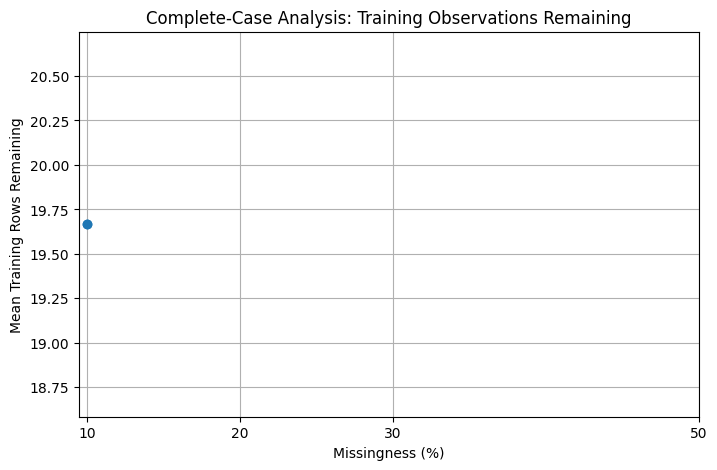

In [20]:
complete_case = summary[
    summary["imputer"] == "Complete-case"
]

plt.figure(figsize=(8, 5))

plt.plot(
    complete_case["missingness"] * 100,
    complete_case["mean_rows_remaining"],
    marker="o"
)

plt.xlabel("Missingness (%)")
plt.ylabel("Mean Training Rows Remaining")
plt.title("Complete-Case Analysis: Training Observations Remaining")
plt.xticks([10, 20, 30, 50])
plt.grid(True)
plt.show()

In [21]:
plot_data = summary[
    (summary["missingness"] > 0) &
    (summary["imputer"].isin(["Mean", "Median", "KNN"]))
]

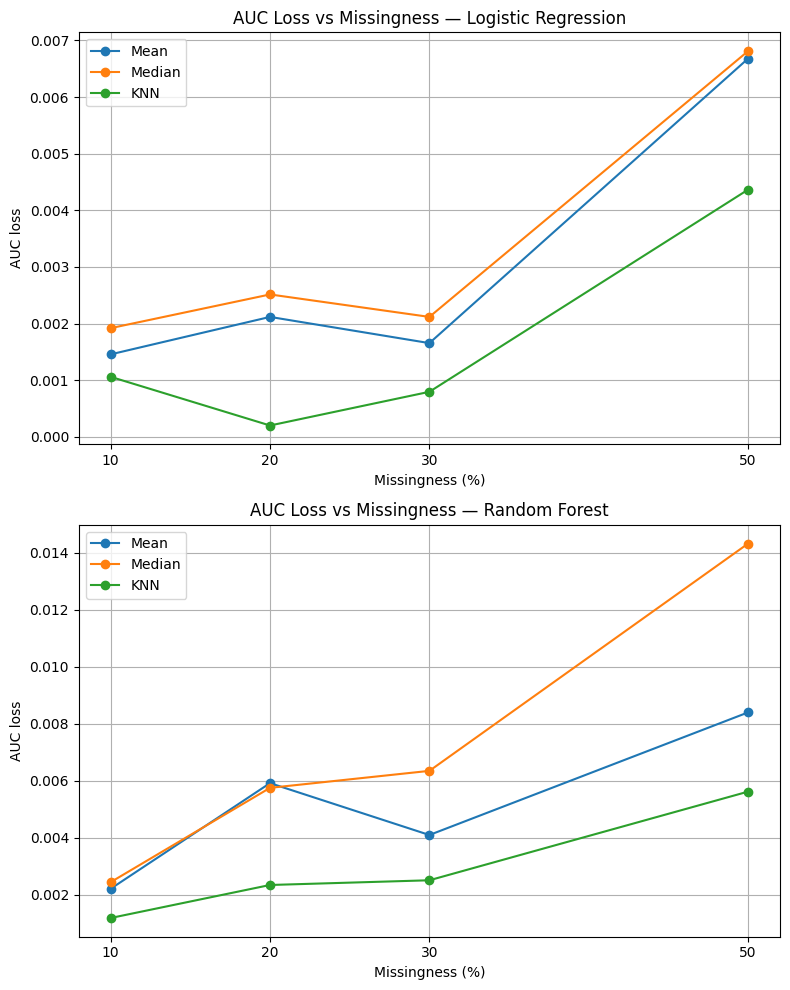

In [22]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(8, 10))

for ax, model in zip(
    axes,
    ["Logistic Regression", "Random Forest"]
):

    model_data = plot_data[
        plot_data["model"] == model
    ]

    for imputer in ["Mean", "Median", "KNN"]:

        data = model_data[
            model_data["imputer"] == imputer
        ]

        ax.plot(
            data["missingness"] * 100,
            data["auc_loss"],
            marker="o",
            label=imputer
        )

    ax.set_xlabel("Missingness (%)")
    ax.set_ylabel("AUC loss")
    ax.set_title(f"AUC Loss vs Missingness — {model}")
    ax.set_xticks([10, 20, 30, 50])
    ax.legend()
    ax.grid(True)

plt.tight_layout()

plt.savefig(
    "figures/performance_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Discussion

### Final classical imputation results
Increasing MCAR missingness generally reduced predictive performance. The effect was more apparent for Accuracy and F1 than for ROC-AUC, particularly at 50% missingness. Logistic Regression remained relatively robust, with KNN-imputed data achieving an AUC of 0.9910 at 50% missingness compared with 0.9954 on complete data. Random Forest showed a slightly larger reduction in AUC, from 0.9937 on complete data to 0.9881 with KNN at 50% missingness.

KNN imputation achieved the highest mean AUC among the three imputation methods at every tested missingness level for both Logistic Regression and Random Forest. Its advantage was relatively small at lower missingness levels but became more noticeable at 50% missingness, particularly for Random Forest. KNN also generally achieved the highest Accuracy and F1 across the tested conditions.

Complete-case analysis resulted in substantial loss of observations. At 10% missingness, only approximately 20 training observations remained on average, compared with 455 observations when using imputation. Therefore, complete-case performance is not directly comparable with the imputation approaches and demonstrates the potential inefficiency of discarding incomplete observations in a high-dimensional dataset.
